# Análise e ajustes de modelos de série temporal com covariáveis

## Séries Temporais - A2

**Integrantes:**

- Gustavo Tironi
- Kauan Mariani Ferreira
- Lívia Verly
- Matheus Fillype Ferreira de Carvalho
- Pedro Henrique Coterli
- Sillas Rocha da Costa

## 0. Setup e carregamento dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [138]:
# Carregando os dados
data = pd.read_csv('data_updated.csv')
data['week'] = pd.to_datetime(data['week'])
data = data.set_index('week')

print(f"Período dos dados: {data.index.min()} até {data.index.max()}")
print(f"Total de observações: {len(data)}")
print(f"\nPrimeiras linhas:")
data.head(10)

Período dos dados: 2022-10-31 00:00:00 até 2025-10-27 00:00:00
Total de observações: 157

Primeiras linhas:


,volume,inv,users
week,,,
2022-10-31,0.38,1.609882,6.500
2022-11-07,0.47,1.880548,7.061
2022-11-14,0.32,2.297810,5.875
2022-11-21,1.69,5.623875,24.238
2022-11-28,1.23,1.473418,7.648
2022-12-05,0.77,0.691911,4.105
2022-12-12,0.49,0.335866,2.060
2022-12-19,0.14,0.182806,0.655
2022-12-26,0.39,0.182695,0.778


## 1. Análise exploratória multivariada e correlações

### 1.1. Visualização das séries

Nesta seção, realizaremos a análise exploratória dos dados com as variáveis `volume`, `inv` e `users`, a fim de identificar características que direcionem os modelos que serão ajustados.

Primeiramente, observemos o comportamento de cada série individualmente e em conjunto com suas versões normalizadas (cada série possui uma unidade de medida e uma escala diferentes).

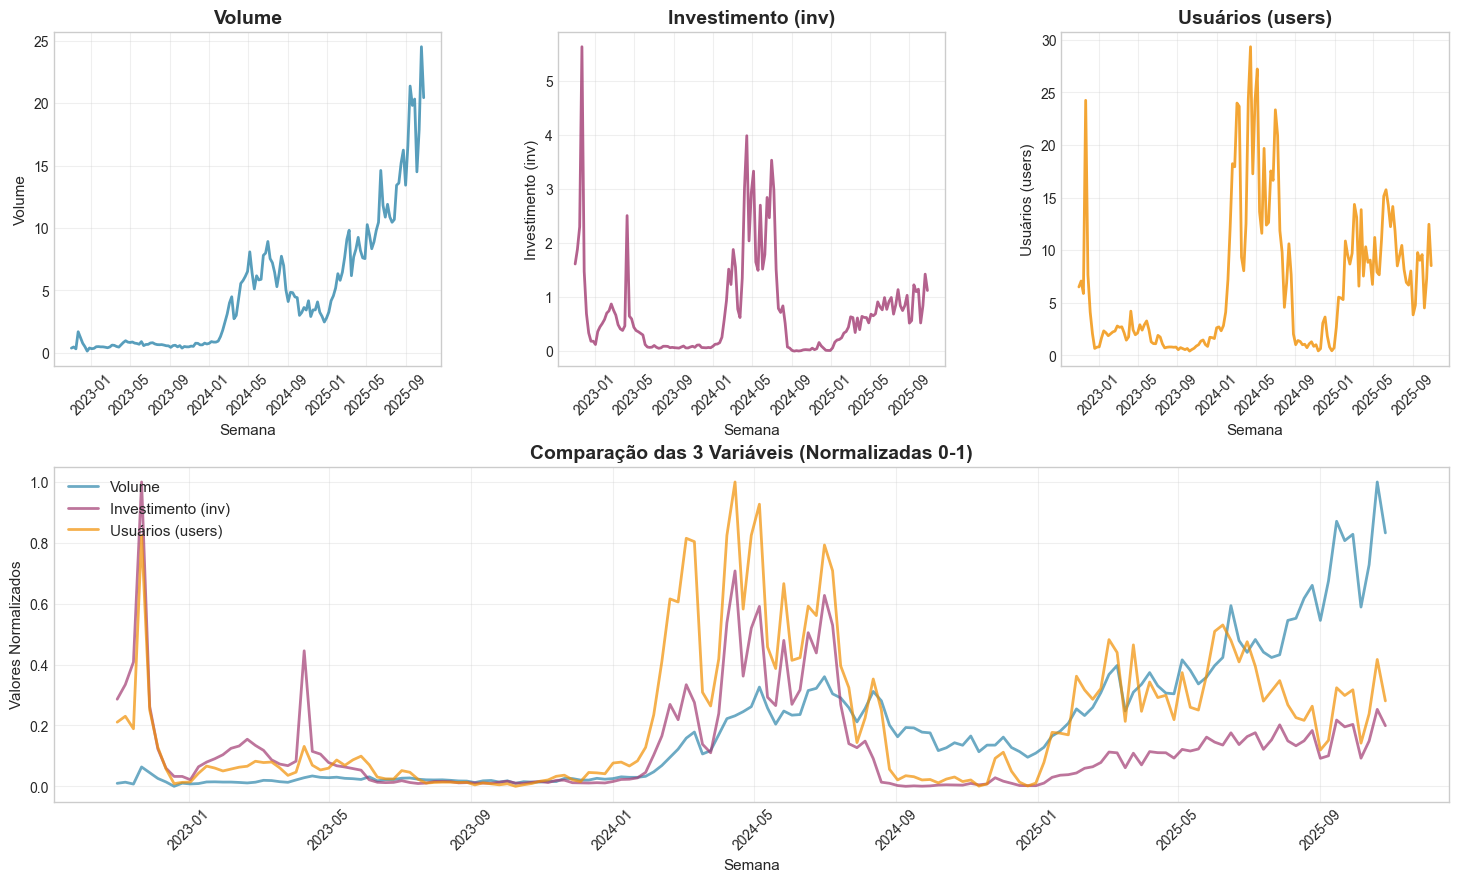

In [139]:
# Figura com 3 gráficos em cima e 1 embaixo
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Cores para cada variável
colors = {'volume': '#2E86AB', 'inv': '#A23B72', 'users': '#F18F01'}

# Gráficos individuais em cima (3 colunas)
variables = ['volume', 'inv', 'users']
titles = ['Volume', 'Investimento (inv)', 'Usuários (users)']

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(data.index, data[var], color=colors[var], linewidth=2, alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Semana', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Gráfico combinado embaixo (ocupando as 3 colunas)
ax_combined = fig.add_subplot(gs[1, :])

# Normalizar os dados para plotar juntos (escala 0-1)
data_normalized = (data - data.min()) / (data.max() - data.min())

for var, title in zip(variables, titles):
    ax_combined.plot(data.index, data_normalized[var],
                     label=title, color=colors[var], linewidth=2, alpha=0.7)

ax_combined.set_title('Comparação das 3 Variáveis (Normalizadas 0-1)',
                      fontsize=14, fontweight='bold')
ax_combined.set_xlabel('Semana', fontsize=11)
ax_combined.set_ylabel('Valores Normalizados', fontsize=11)
ax_combined.legend(loc='upper left', fontsize=11)
ax_combined.grid(True, alpha=0.3)
ax_combined.tick_params(axis='x', rotation=45)

plt.show()

Como podemos ver, parece haver uma relação forte entre as covariáveis `users` e `inv`, com ambas seguindo o mesmo padrão, principalmente nos picos ocorridos em 2022 e na metade de 2024. Por outro lado, nossa variável target `volume` ou não corresponde a isso ou corresponde de forma mais suave. Além disso, ao final da série, vemos uma força de crescimento muito maior nessa variável do que nas outras.

### 1.2. Autocorrelação da variável target `volume`

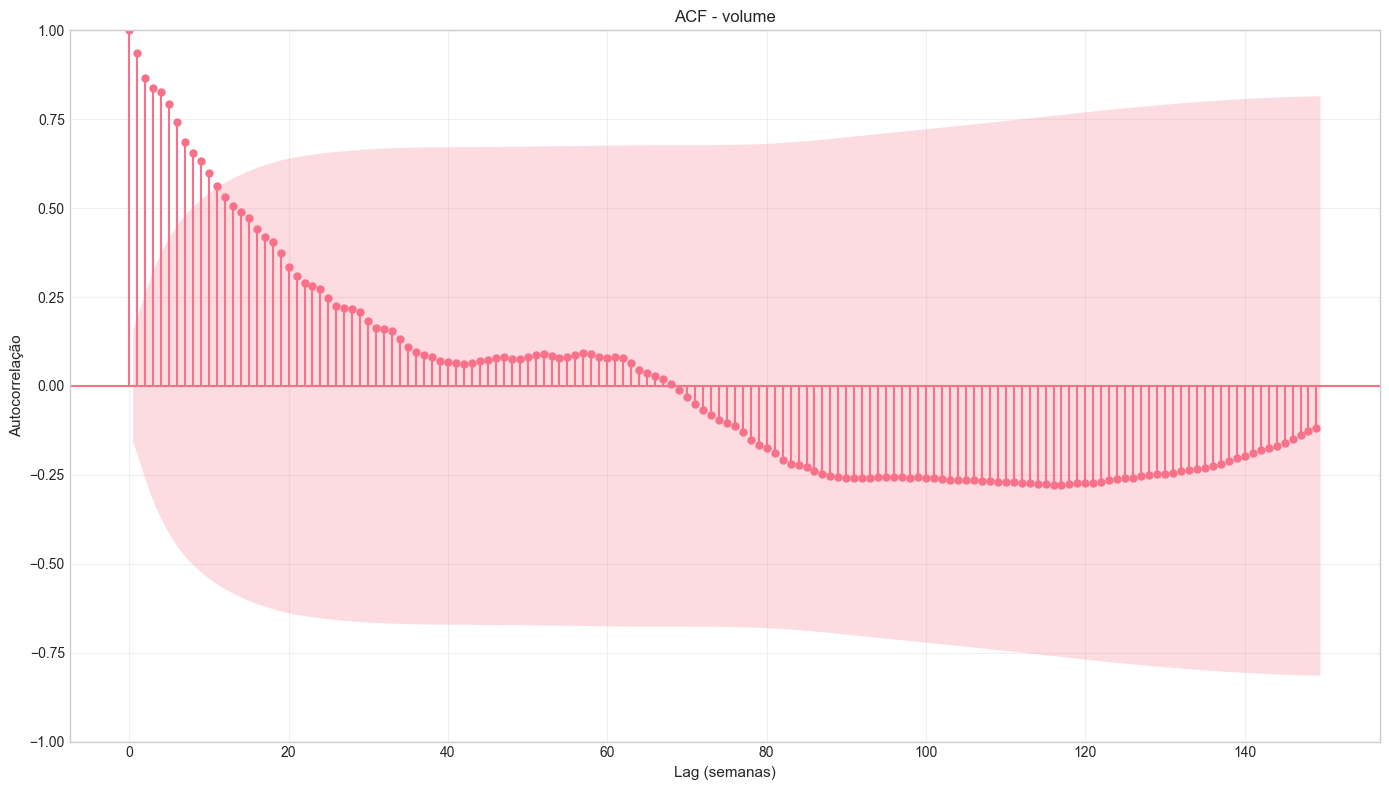

In [140]:
# Plotando a ACF da variável target
plot_acf(data["volume"], lags=149, alpha=0.05, title=f'ACF - volume')
plt.xlabel('Lag (semanas)', fontsize=11)
plt.ylabel('Autocorrelação', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ao analisar esse gráfico, vemos uma persistência significativa nos primeiros lags, com um decaimento suave característico de séries não-estacionárias com forte componente de tendência, sugerindo que a inércia da própria série é um componente preditivo essencial. Isso indica antecipadamente que os modelos baseados apenas em covariáveis externos (como o TSLM simples, que será analisado na seção 2) provavelmente deixarão autocorrelação residual, exigindo uma abordagem de regressão dinâmica para capturar essa estrutura de memória.

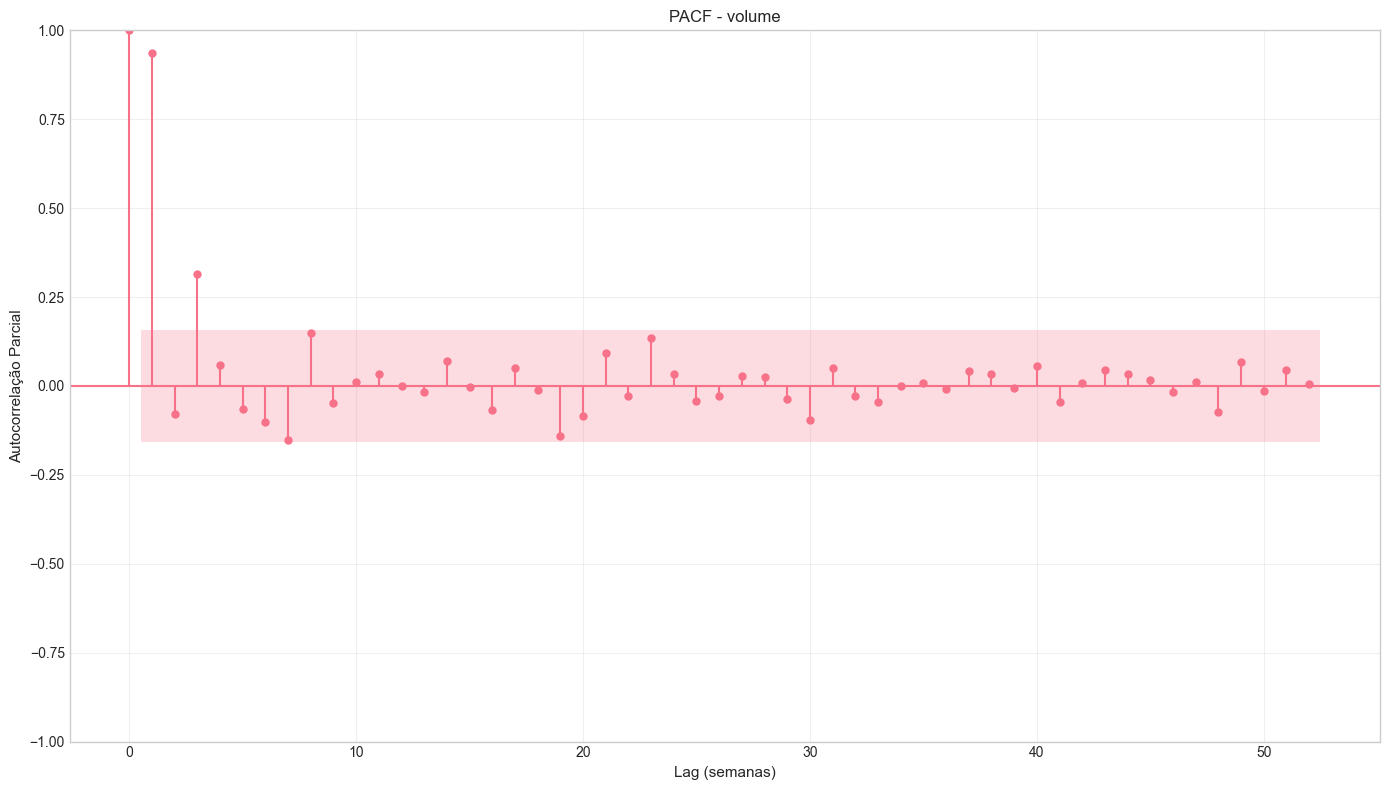

In [141]:
# Plotando a PACF da variável target
plot_pacf(data["volume"], lags=52, alpha=0.05, title=f'PACF - volume')
plt.xlabel('Lag (semanas)', fontsize=11)
plt.ylabel('Autocorrelação Parcial', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Já esse gráfico da PACF da target `volume` confirma a estrutura auto-regressiva dessa variável, com um corte de significância abrupto após o lag 1, o que sugere um processo gerador AR de ordem 1. Esses resultados serão utilizados para o ajuste dos modelos ARIMA na seção 4.

### 1.3. Teste de sazonalidade

A seguir, vamos realizar a decomposição STL da variável `volume` para verificar se existe alguma componente sazonal relevante. Para isso, faremos a decomposição com janelas de 4 semanas (mensal) e 52 semanas (anual).

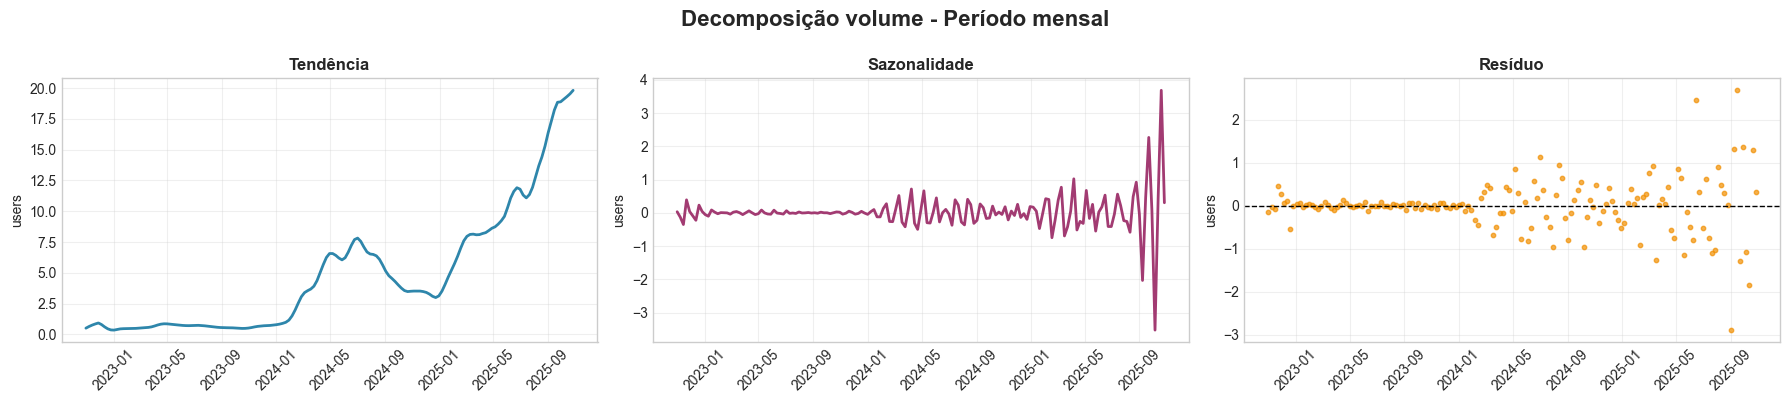

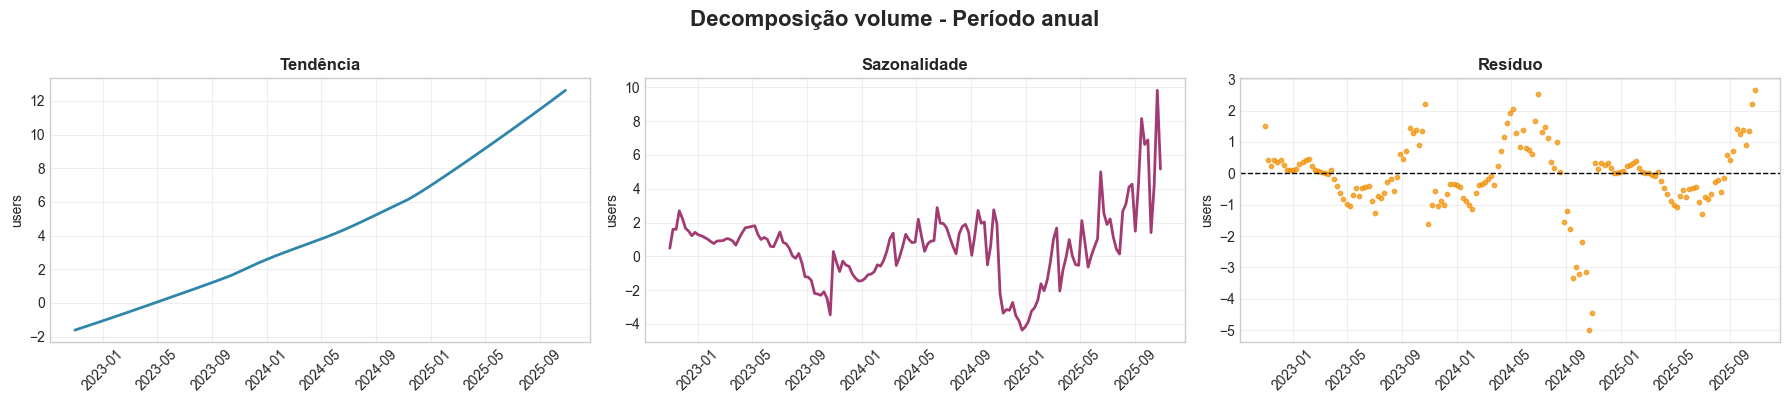

In [142]:
for period in [4, 52]:    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Decomposição mensal usando STL7
    decomp = STL(data["volume"], period=period).fit()

    # Tendência
    axes[0].plot(decomp.trend, color='#2E86AB', linewidth=2)
    axes[0].set_title(f'Tendência', fontsize=12, fontweight='bold')
    axes[0].set_ylabel(var, fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Sazonalidade
    axes[1].plot(decomp.seasonal, color='#A23B72', linewidth=2)
    axes[1].set_title(f'Sazonalidade', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(var, fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    # Resíduo (scatter plot)
    axes[2].scatter(decomp.resid.index, decomp.resid, color='#F18F01', alpha=0.7, s=10)
    axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[2].set_title(f'Resíduo', fontsize=12, fontweight='bold')
    axes[2].set_ylabel(var, fontsize=10)
    axes[2].grid(True, alpha=0.3)
    axes[2].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Decomposição volume - Período {"mensal" if period == 4 else "anual"}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

Como podemos ver, com período semanal, a componente sazonal apresenta baixa amplitude relativa, sendo irrelevante quando comparada com a tendência. E, com período anual, embora a sazonalidade agora possua impacto significativo, os resíduos possuem uma estrutura que claramente não é ruidosa.

No entanto, na decomposição mensal, observamos ruídos com amplitude maior no final da série, quando a variável `volume` apresenta valores maiores. Isso sugere fortemente uma heterocedasticidade dos dados. Dessa forma, vamos aplicar uma transformação $\log$ nessa variável e tentar novamente realizar a decomposição STL.

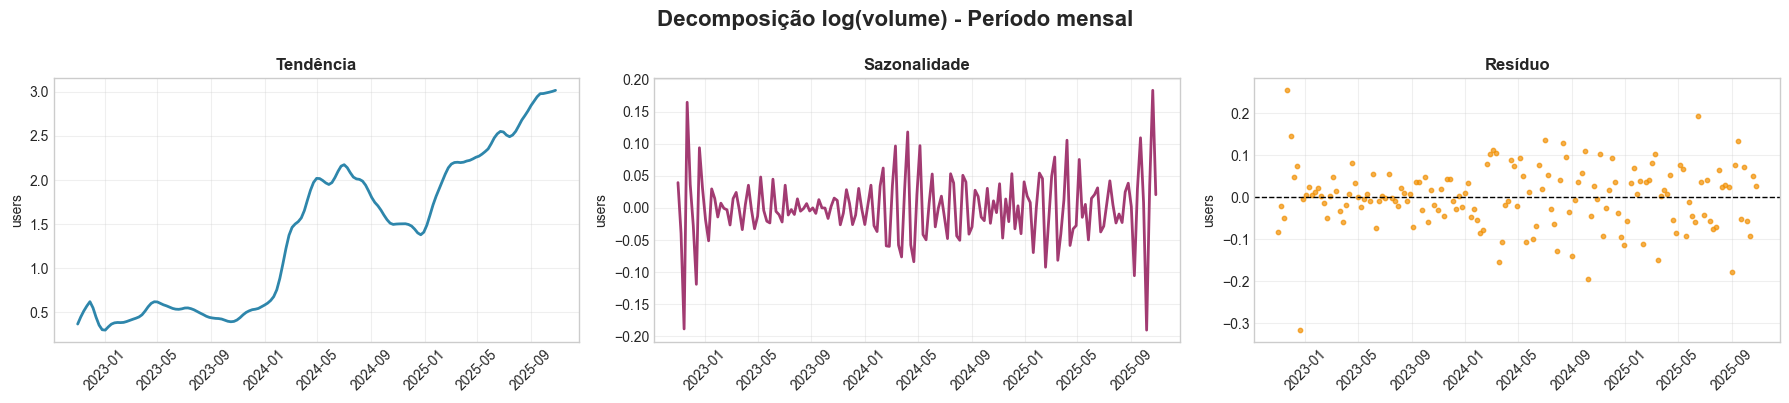

In [143]:
# Tranformação
data_log = data.copy()
data_log[f'volume_log'] = np.log1p(data["volume"])

# Decomposição mensal usando STL7
decomp = STL(data_log["volume_log"], period=4).fit()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Tendência
axes[0].plot(decomp.trend, color='#2E86AB', linewidth=2)
axes[0].set_title(f'Tendência', fontsize=12, fontweight='bold')
axes[0].set_ylabel(var, fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sazonalidade
axes[1].plot(decomp.seasonal, color='#A23B72', linewidth=2)
axes[1].set_title(f'Sazonalidade', fontsize=12, fontweight='bold')
axes[1].set_ylabel(var, fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Resíduo (scatter plot)
axes[2].scatter(decomp.resid.index, decomp.resid, color='#F18F01', alpha=0.7, s=10)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_title(f'Resíduo', fontsize=12, fontweight='bold')
axes[2].set_ylabel(var, fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(f'Decomposição log(volume) - Período mensal', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Agora, obtivemos um resíduo com estrutura razoavelmente aleatória, indicando o sucesso da aplicação da transformação $\log$. No entanto, a componente sazonal continua com uma amplitude descartável. Portanto, optaremos por não incluir componentes sazonais nos ajustes dos nossos modelos, mas utilizaremos a transformação logarítmica da variável target.

In [144]:
data_log[f'inv_log'] = np.log1p(data["inv"])
data_log[f'users_log'] = np.log1p(data["users"])

### 1.4. Correlações com as covariáveis

Em seguida, faremos gráficos de dispersão da variável target `volume` contra as covariáveis `inv` e `users`, tanto com a target original quanto com a versão transformada por $\log$, para avaliar a significância das covariáveis para explicar a `volume`.

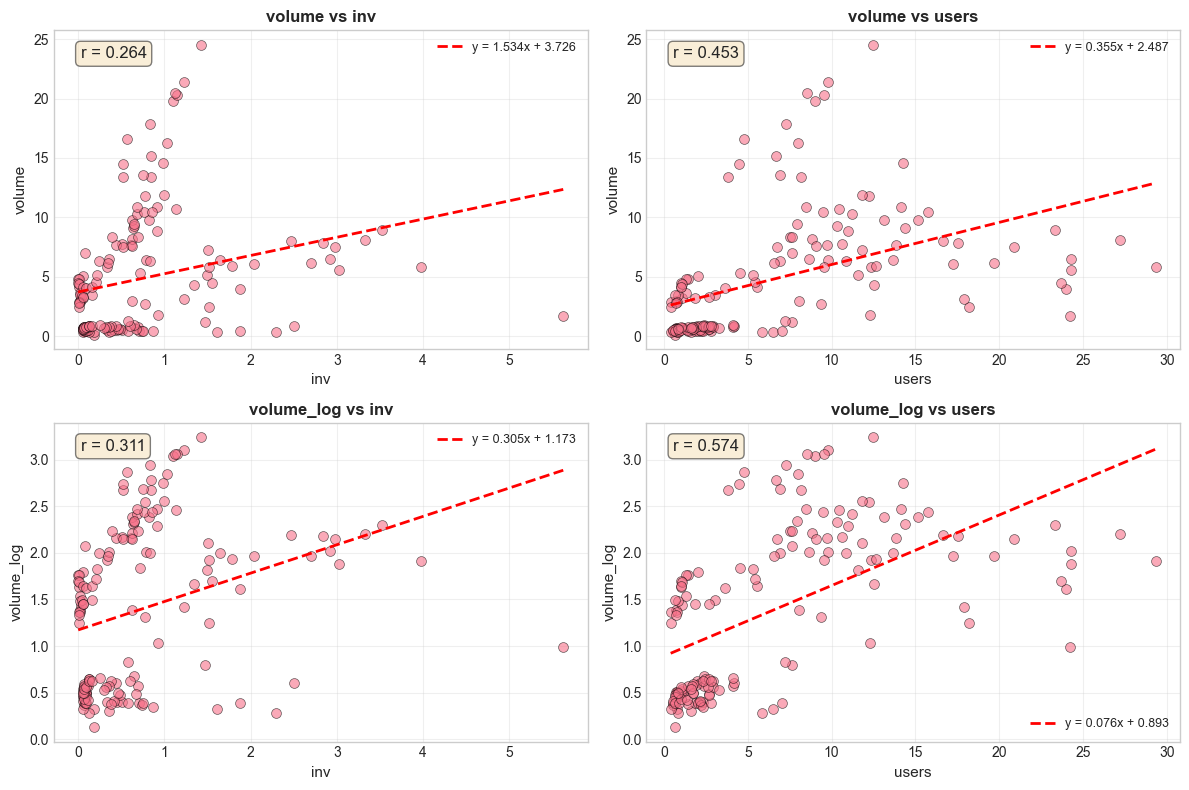

In [145]:
# Scatter plots com linha de tendência (volume original)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs = [('inv', 'volume'), ('users', 'volume'), ('inv', 'volume_log'), ('users', 'volume_log')]

for i, (var1, var2) in enumerate(pairs):
    ax = axes[i // 2, i % 2]
    
    # Scatter
    ax.scatter(data_log[var1], data_log[var2], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    # Linha de tendência
    z = np.polyfit(data_log[var1], data_log[var2], 1)
    p = np.poly1d(z)
    ax.plot(data_log[var1].sort_values(), p(data_log[var1].sort_values()),
            "r--", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

    # Correlação
    corr = data_log[var1].corr(data_log[var2])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_xlabel(var1, fontsize=11)
    ax.set_ylabel(var2, fontsize=11)
    ax.set_title(f'{var2} vs {var1}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Pode-se ver que ambas as variáveis possuem certa correlação com a variável target, indicando potencial preditivo. Entretanto, nas versões com a target original (linha superior), os pontos se distanciam consideravelmente da reta ajustada à medida que o valor das variáveis aumenta, indicando a presença de heterocedasticidade. Com isso, as versões com transformação logarítmica da `volume` apresentam uma correlação mais regular e significativa, mais uma vez reforçando a necessidade da utilização dessa transformação.

Além disso, os valores das covariáveis `inv` e `users` também aparentam ter uma distribuição assimétrica à direita, com uma grande concentração de pontos em valores baixos e uma escassez de registros com valores maiores. Isso sugere a aplicação de transformações logarítmicas também a essas covariáveis, o que será considerado no ajuste dos modelos TSLM na seção 2.

### 1.5. Correlação cruzada

Por fim, vamos analisar a correlação cruzada entre a variável `volume` já com transformação logarítmica e as covariáveis `inv` e `users`, com o objetivo de verificar o imediatismo do impacto dos valores dessas covariáveis na variável target ou a amplitude de seu lag.

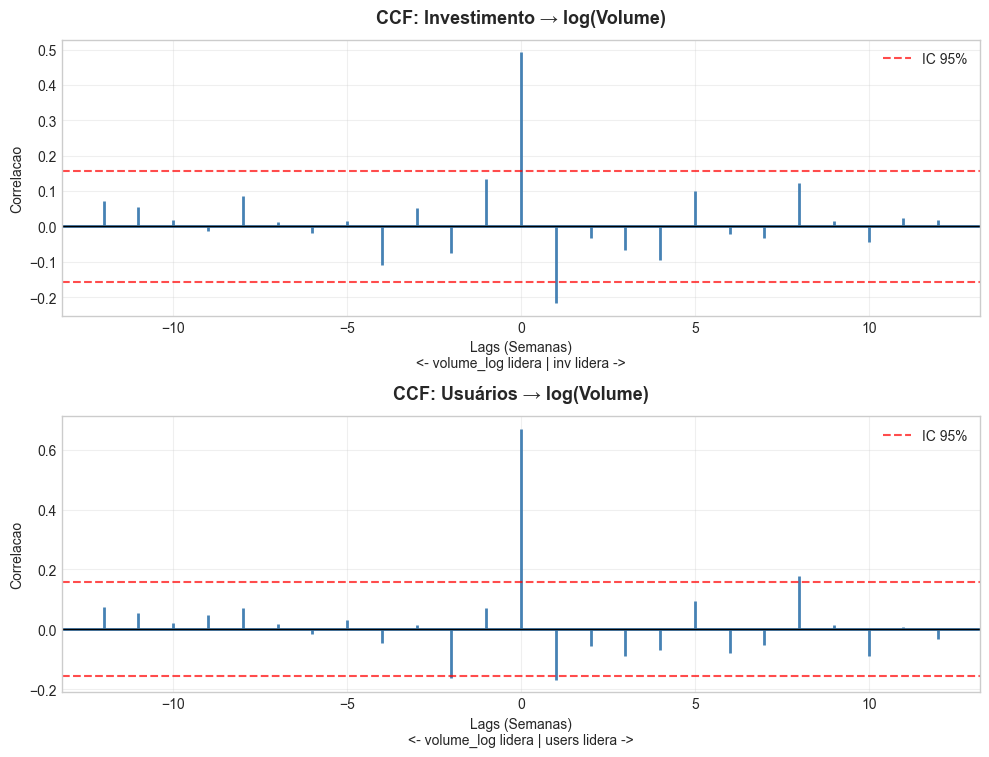

In [146]:
data["volume_log"] = np.log1p(data["volume"])

data_diff = data.diff().dropna()

max_lag = 12
pares = [
    ('inv', 'volume_log', 'Investimento → log(Volume)'),
    ('users', 'volume_log', 'Usuários → log(Volume)'),
]

fig, axes = plt.subplots(len(pares), 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.5)

for i, (var_x, var_y, titulo) in enumerate(pares):
    ax = axes[i]

    temp_df = data_diff[[var_x, var_y]].dropna()
    x = temp_df[var_x].values
    y = temp_df[var_y].values

    lags_plot, corrs_plot, _, _ = ax.xcorr(
        x, y,
        maxlags=max_lag,
        usevlines=True,
        normed=True,
        lw=2,
        color='steelblue'
    )

    n = len(x)
    limite = 1.96 / np.sqrt(n)
    ax.axhline(limite, color='red', linestyle='--', alpha=0.7, label='IC 95%')
    ax.axhline(-limite, color='red', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)

    ax.set_title(f"CCF: {titulo}", fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel("Correlacao")
    ax.set_xlabel(f"Lags (Semanas)\n<- {var_y} lidera | {var_x} lidera ->")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    sig_mask = np.abs(corrs_plot) > limite
    lags_sig = lags_plot[sig_mask]
    corrs_sig = corrs_plot[sig_mask]

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observando o lado direito desses gráficos, é possível ver que, tanto para `inv` quanto para `users`, existe uma alta correlação imediata entre elas e a `volume_log`, com valores significativos nos lags 0 e 1. No entanto, como não saberemos os valores dessas covariáveis na exata semana da qual queremos prever `volume`, então consideraremos aqui apenas o lag 1. Além disso, para a covariável `users`, podemos ver uma interação significativa entre ela e a variável target com 8 semanas de lag (2 meses), o que levanta a hipótese de um ciclo de maturação ou conversão tardia da base de usuários. Levaremos isso em consideração ao testar ajustes de modelos na próxima seção.

## 2. Modelagem TSLM

Nesta seção, realizaremos o ajuste de modelos lineares simples (sem autoregressão), utilizando as covariáveis disponíveis e algumas combinações e transformações derivadas dos resultados da seção anterior.

Inicialmente, vale ressaltar que todos os modelos ajustados a seguir serão baseados na transformação logarítmica da variável target `volume`, dadas as diversas evidências de heterocedasticidade apresentadas anteriormente.

Serão ajustados 3 modelos lineares para séries temporais:

- **Simples**: $\log$(`volume`) ~ `inv_lag_1` + `users_lag_1` + `users_lag_8`
- **Tendência**: $\log$(`volume`) ~ `inv_lag_1` + `users_lag_1` + `users_lag_8` + `trend`
- **Elasticidade**: $\log$(`volume`) ~ $\log$(`inv_lag_1`) + $\log$(`users_lag_1`) + $\log$(`users_lag_8`) + `trend`

Assim, iniciamos com um modelo simples, contendo apenas as covariáveis disponíveis e seus respectivos lags analisados na seção 1.5. Em seguida, adicionamos a componente de tendência, visível como relevante na seção 1.2. Por fim, testamos uma abordagem $\log$-$\log$, aplicando uma transformação logarítmica também nas covariáveis e em seus lags, como sugerido na seção 1.4.

### 2.1. Ajustes iniciais

In [147]:
# Criando as colunas derivadas
data["inv"] = data["inv"].shift(1)
data["users"] = data["users"].shift(1)
data["log_inv"] = np.log1p(data["inv"])
data["log_users"] = np.log1p(data["users"])
data["users_lag_8"] = data["users"].shift(7)
data["users_log_lag_8"] = np.log1p(data["users_lag_8"])
data["trend"] = np.arange(len(data))

data.dropna(inplace=True)

# Separando as covariáveis
X = data.drop('volume', axis=1)
y = data['volume']

# Aplicando o log na target
y_log = np.log1p(y)

data.head()

,volume,inv,users,volume_log,log_inv,log_users,users_lag_8,users_log_lag_8,trend
week,,,,,,,,,
2022-12-26,0.39,0.182806,0.655,0.329304,0.167889,0.503801,6.500,2.014903,8
2023-01-02,0.33,0.182695,0.778,0.285179,0.167795,0.575489,7.061,2.087038,9
2023-01-09,0.36,0.121898,0.808,0.307485,0.115022,0.592221,5.875,1.927892,10
2023-01-16,0.49,0.361241,1.641,0.398776,0.308397,0.971158,24.238,3.228351,11
2023-01-23,0.50,0.448260,2.323,0.405465,0.370363,1.200868,7.648,2.157328,12


In [148]:
log_models = {}

predictions = {}
models = {}

models_cols = {
    "Simples": ["inv", "users", "users_lag_8"],
    "Tendência": ["trend", "inv", "users", "users_lag_8"],
    "Elasticidade": ["trend", "log_inv", "log_users", "users_log_lag_8"],
}

results = {}

for model_name, cols in models_cols.items():
    X_model = sm.add_constant(X[cols])

    model = sm.OLS(y_log, X_model).fit()
    log_models[model_name] = model

    metrics = {}

    metrics["Adjusted R²"] = log_models[model_name].rsquared_adj
    metrics["AIC"] = log_models[model_name].aic
    metrics["BIC"] = log_models[model_name].bic

    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by="Adjusted R²", ascending=False))

,Adjusted R²,AIC,BIC
Elasticidade,0.966618,-122.155783,-107.136051
Tendência,0.945651,-49.532882,-34.513150
Simples,0.493994,281.935234,293.951019


Como podemos ver, a simples adição de uma componente de tendência melhora muito o desempenho do modelo, aumentando em aproximadamente 0.45 o valor do coeficiente R² ajustado, o que demonstra a presença de tendência determinística na variável target.

Em seguida, fica claro que o melhor modelo dentre esses é o modelo de elasticidade, com os logaritmos das covariáveis, que apresenta desempenho superior em todas as métricas consideradas. Isso mostra que a relação entre `volume` e as covariáveis `inv` e `users` não é linear, com o modelo $\log$-$\log$ se ajustando melhor.

### 2.2. Análises de significância

A seguir, vamos analisar a significância das variáveis dos dois melhores modelos.

In [149]:
log_models["Elasticidade"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1072.
Date:                Sun, 30 Nov 2025   Prob (F-statistic):          4.85e-106
Time:                        16:58:59   Log-Likelihood:                 66.078
No. Observations:                 149   AIC:                            -122.2
Df Residuals:                     144   BIC:                            -107.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3996      0.033    -11.971      0.000      -0.466      -0.334
trend               0.0155      0.000     37.616      0.000       0.015       0.016
log_inv             0.4035      0.074      5.436      0.000       0.257       0.550
log_users           0.0626      0.035      1.771      0.079      -0.007       0.133
users_log_lag_8     0.1811      0.020      9.015      0.000       0.141       0.221
==============================================================================
Omnibus:                        2.576   Durbin-Watson:                   0.948
Prob(Omnibus):                  0.276   Jarque-Bera (JB):                2.553
Skew:                           0.269   Prob(JB):                        0.279
Kurtosis:                       2.650   Cond. No.                         578.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

No ajuste do modelo de elasticidade, quase todas as covariáveis mostraram-se fortemente significativas, com apenas `log_users` apresentando-se no limite da significância. Mais adiante, vamos tentar ajustar um modelo sem essa covariável para comparar seu desempenho com o do modelo original.

In [150]:
log_models["Tendência"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 volume   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     644.8
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           8.26e-91
Time:                        16:58:59   Log-Likelihood:                 29.766
No. Observations:                 149   AIC:                            -49.53
Df Residuals:                     144   BIC:                            -34.51
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2092      0.038     -5.573      0.000      -0.283      -0.135
trend           0.0164      0.000     34.727      0.000       0.016       0.017
inv             0.1790      0.049      3.684      0.000       0.083       0.275
users           0.0083      0.006      1.422      0.157      -0.003       0.020
users_lag_8     0.0199      0.003      6.239      0.000       0.014       0.026
==============================================================================
Omnibus:                        6.765   Durbin-Watson:                   0.734
Prob(Omnibus):                  0.034   Jarque-Bera (JB):                3.402
Skew:                           0.095   Prob(JB):                        0.182
Kurtosis:                       2.285   Cond. No.                         287.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Já no modelo de tendência, com as covariáveis originais, novamente, a variável relacionada a `users` é a única com insignificância estatística.

### 2.3. Testes de filtragem de covariáveis

Por fim, ajustamos dois novos modelos: o modelo de elasticidade sem a covariável `log_users` e o modelo de tendência sem a covariável `users`. Vamos avaliar como a remoção dessas covariáveis, que não se mostraram significantes nos ajustes originais, afeta o desempenho desses modelos.

In [151]:
log_models = {}

predictions = {}
models = {}

models_cols.update({
    "Elasticidade (sem log_users)": ["trend", "log_inv", "users_log_lag_8"],
    "Tendência (sem users)": ["trend", "inv", "users_lag_8"],
})

results = {}

for model_name, cols in models_cols.items():
    X_model = sm.add_constant(X[cols])

    model = sm.OLS(y_log, X_model).fit()
    log_models[model_name] = model

    metrics = {}

    metrics["Adjusted R²"] = log_models[model_name].rsquared_adj
    metrics["AIC"] = log_models[model_name].aic
    metrics["BIC"] = log_models[model_name].bic

    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by="Adjusted R²", ascending=False))

,Adjusted R²,AIC,BIC
Elasticidade,0.966618,-122.155783,-107.136051
Elasticidade (sem log_users),0.966126,-120.946180,-108.930395
Tendência,0.945651,-49.532882,-34.513150
Tendência (sem users),0.945268,-49.455646,-37.439861
Simples,0.493994,281.935234,293.951019


Como podemos observar, em ambos os casos, a remoção dessas covariáveis resultou em leves pioras do ajuste dos modelos.

Com relação ao modelo de tendência, valeria a pena descartar a covariável `users`, dado que seu nível de insignificância estatística é bem considerável (p-valor = 0.157) e o modelo consegue performar quase que da mesma forma sem sua inclusão.

Por outro lado, mesmo que a remoção de `log_users` tenha reduzido levemente a qualidade do ajuste, dado que ela ainda encontra-se no limite da significância (p-valor = 0.079, muito próximo do limite usual 0.05), ainda vale a pena mantê-la. Isso é apoiado pelo fato de o coeficiente AIC do modelo de elasticidade original é melhor (menor) que o do modelo sem a covariável, indicando que, matematicamente, a informação ganha ao incluí-la compensa a penalidade de adicionar mais um parâmetro, o que não ocorre na comparação dos modelos de tendência.

Portanto, para as próximas análises, o modelo TSLM a ser considerado será o modelo de `Elasticidade`.

## 3. Diagnóstico de resíduos

Conforme indicado pela análise de modelagem TSLM anterior, o modelo que apresentou o melhor desempenho foi o modelo de `Elasticidade com Tendência` (Log Covars + Trend). O modelo selecionado utiliza a transformação logarítmica na variável target e nas covariáveis, além de incluir um componente de tendência linear e o lag de 8 semanas da variável users. A especificação é: 

$$
    \log(volume)∼trend+\log(inv)+\log(users)+\log(users_{lag8}​)
$$

Nesta parte do trabalho, vamos realizar o diagnóstico dos resíduos deste modelo específico para verificar se as premissas de Mínimos Quadrados Ordinários (OLS) são satisfeitas:

- **Normalidade**: Os resíduos seguem uma distribuição normal?
  
- **Homocedasticidade**: A variância dos resíduos é constante?
  
- **Independência (Ausência de Autocorrelação)**: Restou alguma estrutura temporal nos resíduos que o TSLM não capturou? (Isso motivará o uso de ARIMA na próxima seção).

In [ ]:
# modelos analisados
cols_selected = ["trend", "log_inv", "log_users", "users_log_lag_8"]

# extraindo os resíduos 
X_final = sm.add_constant(X[cols_selected])
model_final = sm.OLS(y_log, X_final).fit()
residuals = model_final.resid

### Visualização e Análise Iniciais

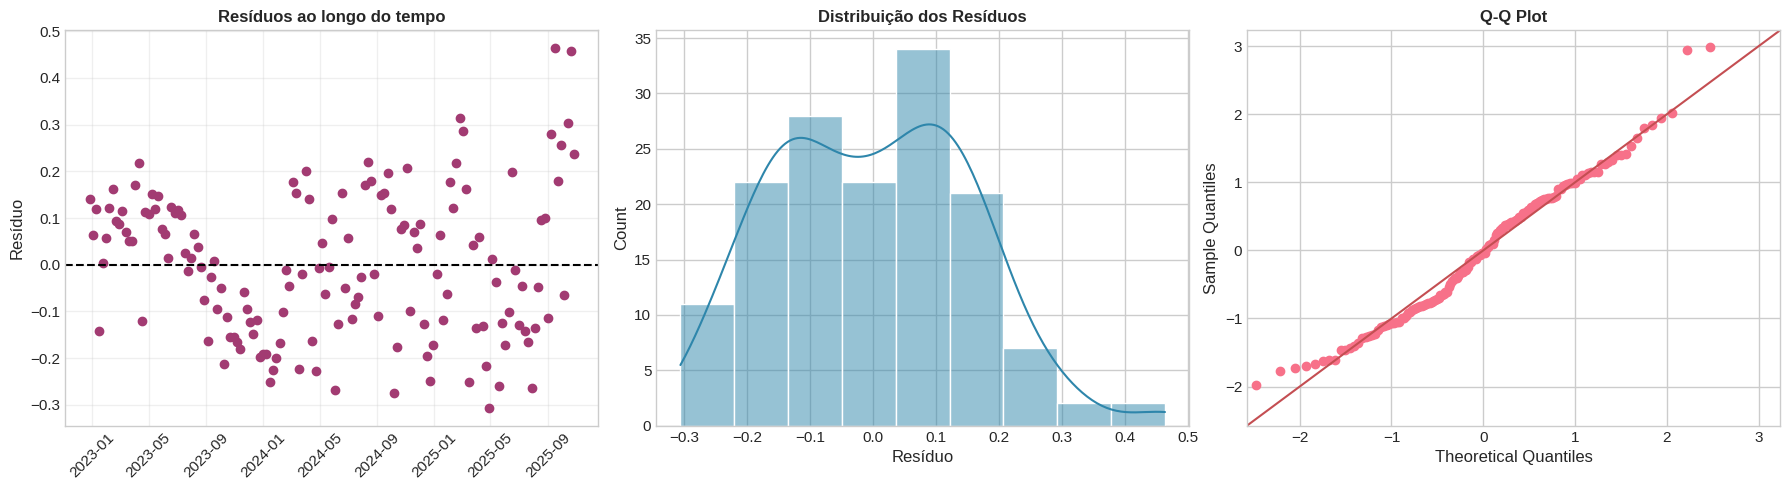

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# resíduos no tempo
axes[0].scatter(residuals.index, residuals, color='#A23B72')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Resíduos ao longo do tempo', fontweight='bold')
axes[0].set_ylabel('Resíduo')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# histograma
sns.histplot(residuals, kde=True, ax=axes[1], color='#2E86AB')
axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1].set_xlabel('Resíduo')

# QQ plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[2])
axes[2].set_title('Q-Q Plot', fontweight='bold')

plt.tight_layout()
plt.show()

Os gráficos acima parecem apontar para a normalidade dos resíduos, mas, para não restar dúvidas, vamos usar o [**Teste de Jaque-Bera**](https://en-wikipedia-org.translate.goog/wiki/Jarque%E2%80%93Bera_test?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc). Ele vai medir principalmente duas coisas: Assimetria (skewness), se a curva está torta para algum lado, e Curtose (kurtosis), se a calda é mais pesada/leve do que deveria ser. A hipótese nula é que os dados são normalmente distribuídos, caso o p-valor seja maior que 0.05, falhamos em recusar tal hipótese. 

In [ ]:
jb_test = stats.jarque_bera(residuals)
print(f"Teste Jarque-Bera: Estatística={jb_test.statistic:.4f}, p-valor={jb_test.pvalue:.4f}")

if jb_test.pvalue > 0.05:
    print("Não rejeitamos a hipótese nula. Os resíduos normais.")
else:
    print("Rejeitamos a hipótese nula. Os resíduos não seguem uma distribuição normal.")

Teste Jarque-Bera: Estatística=2.5534, p-valor=0.2790
Não rejeitamos a hipótese nula. Os resíduos normais.


### Análise de Autocorrelação dos Resíduos

Um dos pontos críticos em séries temporais é garantir que o modelo capturou toda a dependência temporal. Se os resíduos apresentarem autocorrelação significativa, significa que o modelo TSLM deixou alguma informação que poderia ser modelada por uma estrutura AR (Auto-Regressiva) ou MA (Média Móvel).

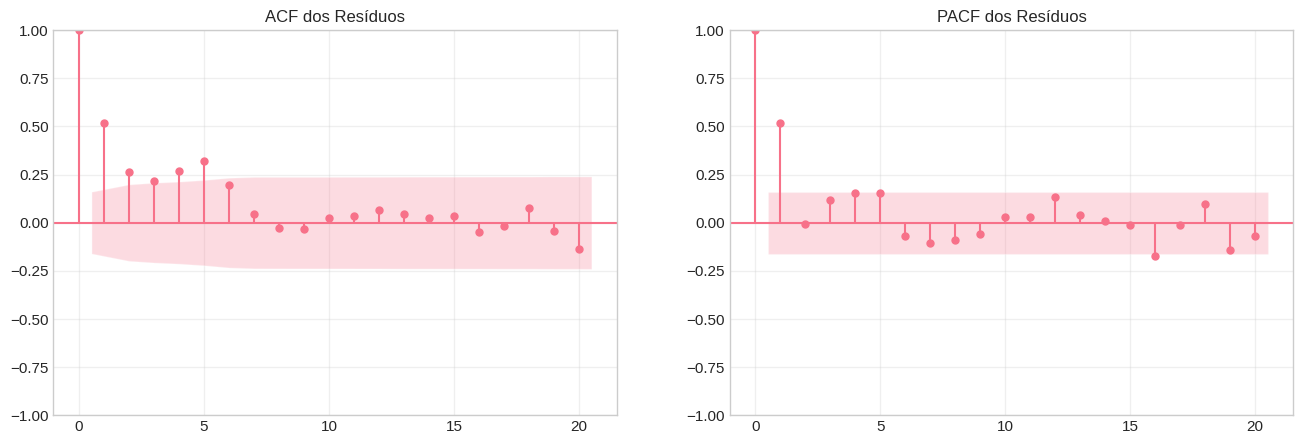

In [ ]:
# plotagem ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(residuals, lags=20, ax=axes[0], title='ACF dos Resíduos', alpha=0.05)
axes[0].grid(True, alpha=0.3)

plot_pacf(residuals, lags=20, ax=axes[1], title='PACF dos Resíduos', alpha=0.05)
axes[1].grid(True, alpha=0.3)

plt.show()

De maneira complementar, vamos usar o [**Teste de Ljung-Box**](https://en-wikipedia-org.translate.goog/wiki/Ljung%E2%80%93Box_test?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc). Ele serve para verificar se a série temporal tem autocorrelação, ou seja, se os valores do passado influenciam ou estão relacionados com os valores do futuro. A ideia não é analisar só um lag específico, mas para vários lags ao mesmo tempo, testando se há algum padrão repetitivo na série. A hipótese nula é que não existe dependência temporal.

In [ ]:
lb_test = acorr_ljungbox(residuals, lags=[20], return_df=True)
print("Teste de Ljung-Box (lag=20):")
display(lb_test)

p_val_lb = lb_test['lb_pvalue'].values[0]
if p_val_lb > 0.05:
    print(f">> P-valor ({p_val_lb:.4f}) > 0.05: Resíduos se comportam como Ruído Branco (sem autocorrelação significativa).")
else:
    print(f">> P-valor ({p_val_lb:.4f}) < 0.05: Resíduos NÃO são Ruído Branco (há estrutura temporal não capturada).")

Teste de Ljung-Box (lag=20):


,lb_stat,lb_pvalue
20,98.834977,2.034589e-12


>> P-valor (0.0000) < 0.05: Resíduos NÃO são Ruído Branco (há estrutura temporal não capturada).


A presença de correlação significativa no primeiro lag confirma o resultado do teste de Ljung-Box. Isso indica que, embora o modelo de regressão (TSLM) tenha capturado bem a tendência e a relação com as covariáveis, ele não capturou a dinâmica inercial da série. O resíduo de hoje ainda depende do resíduo de ontem.

### Resíduos vs Covariáveis

Por fim, verificamos se os resíduos guardam alguma relação com as variáveis explicativas (inv e users). Idealmente, não deve haver padrão visível; uma dispersão aleatória indica que a relação linear (ou log-linear) capturou bem a influência dessas variáveis.

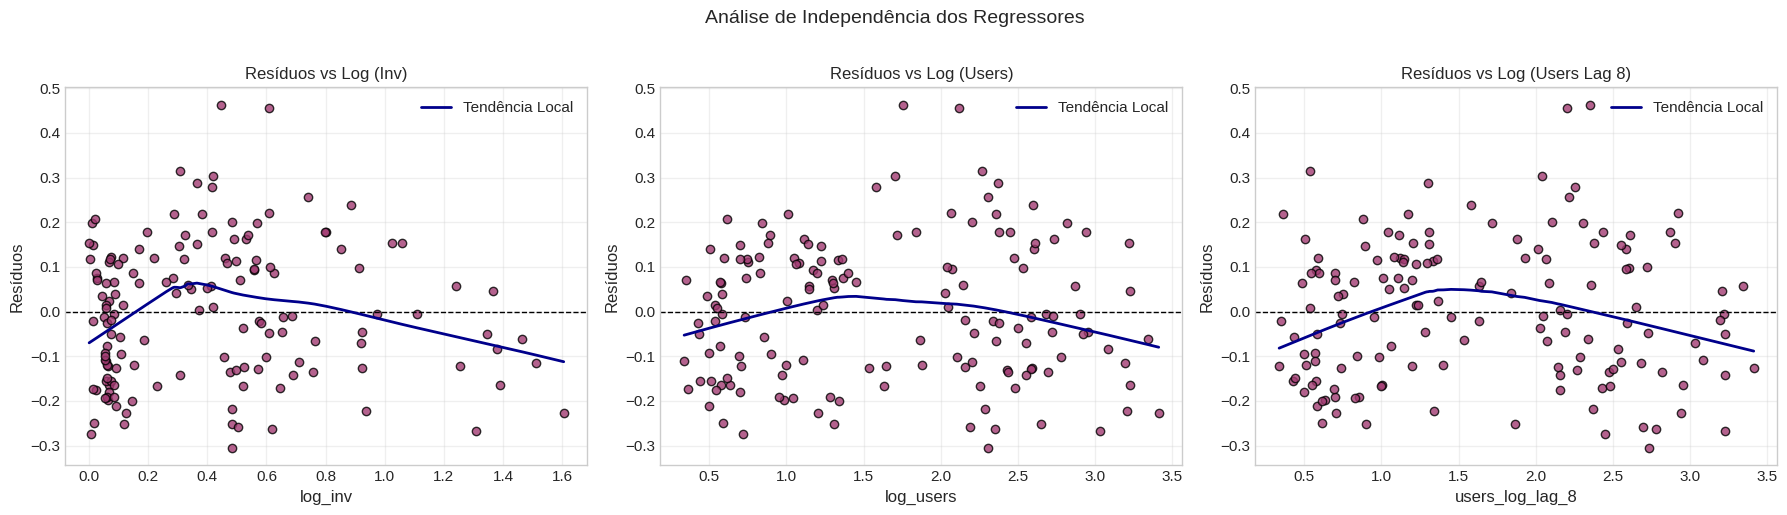

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

covars_check = ['log_inv', 'log_users', 'users_log_lag_8']
titles = ['Log (Inv)', 'Log (Users)', 'Log (Users Lag 8)']

for i, col in enumerate(covars_check):
    # scatter
    axes[i].scatter(X[col], residuals, alpha=0.8, color='#A23B72', edgecolors='black')
    
    axes[i].axhline(0, color='black', linestyle='--', lw=1)
    
    # linha de tendência
    lowess = sm.nonparametric.lowess
    z = lowess(residuals, X[col], frac=0.7)
    axes[i].plot(z[:,0], z[:,1], color='darkblue', lw=2, label='Tendência Local')
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Resíduos')
    axes[i].set_title(f'Resíduos vs {titles[i]}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.suptitle('Análise de Independência dos Regressores', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Estes gráficos validam a escolha funcional do modelo (transformação Log-Log). Eles sugerem que a relação entre a variável target e as covariáveis foi bem capturada e que os resíduos são independentes dos regressores. O erro do modelo não está correlacionado com o valor do investimento ou do número de usuários, o que é um excelente sinal de que as variáveis exógenas foram bem utilizadas.

### Conclusão Etapa 3

Em resumo, o diagnóstico aponta que o modelo TSLM satisfaz as premissas de normalidade e de forma funcional correta (resíduos independentes das covariáveis). No entanto, a premissa de independência temporal falha. Portanto, para obter um modelo robusto e previsões confiáveis, é imperativo modelar essa autocorrelação residual utilizando a metodologia ARIMA na próxima etapa.

## 4. ARIMA com covariáveis

## 5. Previsão e avaliação de performance